<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_C9_Extracci%C3%B3n_Reglas_(Laboratorio).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:#0D1B2A;color:white;padding:30px 40px;border-radius:12px;font-family:sans-serif;">
  <p style="color:#0A9396;font-size:13px;letter-spacing:2px;margin:0;">MINERÍA DE DATOS · 2026</p>
  <h1 style="font-size:30px;margin:10px 0 6px 0;">Extracción de Reglas</h1>
  <h2 style="font-size:17px;color:#A8D8EA;font-weight:300;margin:0 0 16px 0;">
    Reglas de Asociación (Apriori · FP-Growth) &nbsp;|&nbsp;
    Reglas de Clasificación (OneR · PRISM) &nbsp;|&nbsp;
    Árboles como extractores de reglas
  </h2>
  <hr style="border:1px solid #1C7293;margin:16px 0;">
  <p style="font-size:13px;color:#8BADC0;margin:0;">
    Dos paradigmas distintos de extracción de conocimiento desde datos.
    Variables numéricas y cualitativas. Ejemplos 100% ejecutables.
  </p>
</div>

## Estructura del notebook

| Parte | Tema | Algoritmos |
|-------|------|------------|
| **1** | Reglas de Asociación | Apriori, FP-Growth |
| **2** | Reglas de Clasificación | OneR, PRISM |
| **3** | Árboles para Extracción de Reglas | DecisionTree → if/then |
| **4** | Comparativa integral | Los 5 algoritmos sobre el mismo dataset |

> **Datasets:**
> - 🛒 *Grocery Basket* simulado — 1 000 transacciones, 15 productos
> - 🚢 *Titanic* — variables numéricas (Age, Fare) + cualitativas (Sex, Pclass, Embarked)


---
## ⚙️ Setup — instalar y cargar librerías


In [ ]:
# ── Instalar mlxtend si no está disponible ────────────────────────────
try:
    import mlxtend
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "mlxtend", "-q"])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

import time

sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110
print("✅ Librerías cargadas correctamente.")


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

✅ Librerías cargadas correctamente.


---
# 🛒 PARTE 1 — Reglas de Asociación

## Conceptos clave

Las reglas de asociación encuentran **co-ocurrencias frecuentes** en transacciones.
La regla `{pan, manteca} → {mermelada}` se lee:
"quien compra pan y manteca tiende a comprar mermelada".

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **Soporte** | P(A ∪ B) | ¿Qué % de transacciones tiene A y B juntos? |
| **Confianza** | P(B\|A) = P(A ∪ B) / P(A) | Si compran A, ¿con qué prob. compran B? |
| **Lift** | Confianza / P(B) | > 1 = relación positiva; = 1 = independientes |
| **Conviction** | (1-P(B)) / (1-Conf) | Qué tan "convencido" está el modelo |

**Regla práctica:** Lift > 1.5 + Confianza > 0.5 → regla interesante.


### 1.1 Crear el dataset de transacciones


In [ ]:
# ── Dataset simulado: supermercado con 15 productos ──────────────────
np.random.seed(42)
N_TRANS = 1000

PRODUCTOS = [
    "leche", "pan", "manteca", "mermelada", "cafe",
    "azucar", "huevos", "yogur", "queso", "fiambre",
    "manzana", "banana", "agua", "gaseosa", "galletitas"
]

# Patrones de co-ocurrencia realistas
PATRONES = [
    ["leche", "cafe", "azucar"],          # desayuno clásico
    ["pan", "manteca", "mermelada"],       # tostadas
    ["huevos", "manteca", "pan"],          # desayuno salado
    ["yogur", "manzana", "banana"],        # saludable
    ["queso", "fiambre", "pan"],           # sándwich
    ["gaseosa", "galletitas"],             # merienda snack
    ["agua", "manzana"],                   # light
    ["leche", "yogur"],                   # lácteos
]

transacciones = []
for _ in range(N_TRANS):
    # Elegir 1-3 patrones al azar
    n_pat = np.random.randint(1, 4)
    items = set()
    for pat in np.random.choice(len(PATRONES), n_pat, replace=False):
        # Incluir cada item del patrón con probabilidad 0.75
        items.update([p for p in PATRONES[pat] if np.random.rand() < 0.75])
    # Agregar 0-2 items aleatorios
    n_extra = np.random.randint(0, 3)
    items.update(np.random.choice(PRODUCTOS, n_extra, replace=False))
    transacciones.append(sorted(items))

# Estadísticas del basket
sizes = [len(t) for t in transacciones]
print(f"Transacciones: {N_TRANS}")
print(f"Items únicos:  {len(PRODUCTOS)}")
print(f"Tamaño promedio del basket: {np.mean(sizes):.2f} items")
print(f"Rango de tamaño: {min(sizes)} - {max(sizes)} items")
print("\nEjemplo de transacciones:")
for i, t in enumerate(transacciones[:5]):
    print(f"  Transacción {i+1}: {t}")


Transacciones: 1000
Items únicos:  15
Tamaño promedio del basket: 4.55 items
Rango de tamaño: 0 - 10 items

Ejemplo de transacciones:
  Transacción 1: ['gaseosa', 'leche', 'manteca', 'mermelada', 'yogur']
  Transacción 2: ['azucar', np.str_('banana'), 'cafe', 'leche', 'manteca', 'pan']
  Transacción 3: ['huevos', 'leche', np.str_('manteca'), 'pan', 'yogur']
  Transacción 4: [np.str_('azucar'), 'manteca', 'mermelada', np.str_('queso')]
  Transacción 5: [np.str_('banana'), np.str_('cafe'), 'manzana', 'yogur']


Shape de la matriz: (1000, 15)

Frecuencia de items (top 8):
pan           0.515
leche         0.415
yogur         0.407
manzana       0.397
manteca       0.384
galletitas    0.261
gaseosa       0.259
huevos        0.258


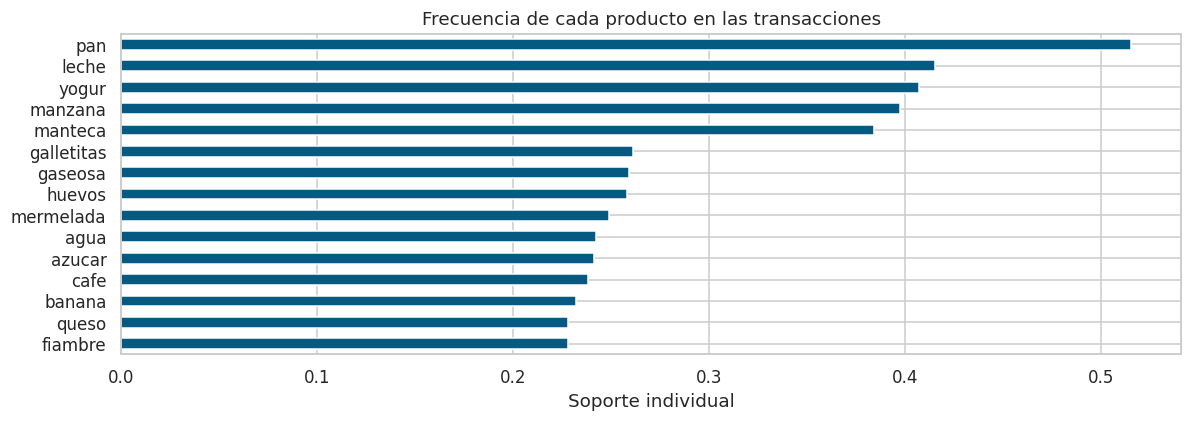

In [ ]:
# ── Convertir a matriz binaria (requerida por mlxtend) ────────────────
te = TransactionEncoder()
te_array = te.fit_transform(transacciones)
df_basket = pd.DataFrame(te_array, columns=te.columns_)

print(f"Shape de la matriz: {df_basket.shape}")
print("\nFrecuencia de items (top 8):")
freq = df_basket.mean().sort_values(ascending=False)
print(freq.head(8).to_string())

# Visualizar frecuencia
plt.figure(figsize=(11, 4))
freq.sort_values().plot(kind="barh", color="#065A82", edgecolor="white")
plt.title("Frecuencia de cada producto en las transacciones")
plt.xlabel("Soporte individual")
plt.tight_layout()
plt.show()


### 1.2 Apriori — Itemsets frecuentes


In [ ]:
# ── Apriori: encontrar itemsets frecuentes ────────────────────────────
MIN_SUPPORT = 0.05  # al menos en el 5% de las transacciones

t0 = time.time()
itemsets_apriori = apriori(
    df_basket,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=4          # máximo 4 items por itemset
)
t_apriori = time.time() - t0

itemsets_apriori["length"] = itemsets_apriori["itemsets"].apply(len)

print(f"Tiempo Apriori: {t_apriori:.3f}s")
print(f"Itemsets frecuentes encontrados: {len(itemsets_apriori)}")
print()
print("Distribución por tamaño:")
print(itemsets_apriori["length"].value_counts().sort_index().to_string())
print()
print("Top 10 itemsets más frecuentes:")
display(itemsets_apriori.sort_values("support", ascending=False).head(10))


Tiempo Apriori: 0.043s
Itemsets frecuentes encontrados: 167

Distribución por tamaño:
length
1    15
2    91
3    58
4     3

Top 10 itemsets más frecuentes:


,support,itemsets,length
12,0.515,(pan),1
8,0.415,(leche),1
14,0.407,(yogur),1
10,0.397,(manzana),1
9,0.384,(manteca),1
93,0.314,"(pan, manteca)",2
5,0.261,(galletitas),1
6,0.259,(gaseosa),1
7,0.258,(huevos),1
11,0.249,(mermelada),1


### 1.3 FP-Growth — Alternativa más eficiente


In [ ]:
# ── FP-Growth: mismo resultado, estructura de árbol interno ──────────
t0 = time.time()
itemsets_fpg = fpgrowth(
    df_basket,
    min_support=MIN_SUPPORT,
    use_colnames=True,
    max_len=4
)
t_fpg = time.time() - t0

itemsets_fpg["length"] = itemsets_fpg["itemsets"].apply(len)

print(f"Tiempo FP-Growth: {t_fpg:.3f}s")
print(f"Itemsets frecuentes: {len(itemsets_fpg)}")

# ── Comparativa de velocidad ──────────────────────────────────────────
print(f"\n=== COMPARATIVA ===")
print(f"Apriori:   {t_apriori:.4f}s  →  {len(itemsets_apriori)} itemsets")
print(f"FP-Growth: {t_fpg:.4f}s  →  {len(itemsets_fpg)} itemsets")
speedup = t_apriori / t_fpg if t_fpg > 0 else float("inf")
print(f"FP-Growth es {speedup:.1f}x más rápido en este dataset")
print()
print("¿Mismo resultado? Los itemsets deben ser idénticos (orden puede variar):")
sets_ap  = set(frozenset(x) for x in itemsets_apriori["itemsets"])
sets_fpg = set(frozenset(x) for x in itemsets_fpg["itemsets"])
print(f"  Itemsets sólo en Apriori:   {len(sets_ap - sets_fpg)}")
print(f"  Itemsets sólo en FP-Growth: {len(sets_fpg - sets_ap)}")
print(f"  En común:                   {len(sets_ap & sets_fpg)}")


Tiempo FP-Growth: 2.603s
Itemsets frecuentes: 167

=== COMPARATIVA ===
Apriori:   0.0427s  →  167 itemsets
FP-Growth: 2.6029s  →  167 itemsets
FP-Growth es 0.0x más rápido en este dataset

¿Mismo resultado? Los itemsets deben ser idénticos (orden puede variar):
  Itemsets sólo en Apriori:   0
  Itemsets sólo en FP-Growth: 0
  En común:                   167


### ¿Por qué FP-Growth es más rápido?

| Aspecto | Apriori | FP-Growth |
|---------|---------|----------|
| **Estrategia** | Genera candidatos iterativamente (k=1, 2, 3...) | Construye un árbol FP-Tree comprimido |
| **Lecturas del dataset** | Múltiples pasadas (una por nivel) | Sólo 2 pasadas |
| **Bottleneck** | Generación y pruning de candidatos | Construcción del árbol |
| **Ventaja** | Simple de entender e implementar | Escala a datasets grandes |
| **Resultado** | Idéntico | Idéntico |

> En la práctica: **FP-Growth siempre que el dataset sea grande**. Apriori para entender el concepto.


### 1.4 Generar y filtrar Reglas de Asociación


In [ ]:
# ── Generar reglas desde los itemsets ────────────────────────────────
# Usamos FP-Growth (más rápido) como base
reglas = association_rules(
    itemsets_fpg,
    metric="lift",
    min_threshold=1.0   # lift > 1.0 = relación positiva
)

# Redondear para legibilidad
reglas = reglas.round(4)

print(f"Total de reglas generadas: {len(reglas)}")
print("\nColumnas disponibles:")
print(reglas.columns.tolist())
print()
print("Primeras 5 reglas:")
display(reglas[["antecedents","consequents","support","confidence","lift"]].head())


Total de reglas generadas: 324

Columnas disponibles:
['antecedents', 'consequents', 'antecedent support', 'consequent support', 'support', 'confidence', 'lift', 'representativity', 'leverage', 'conviction', 'zhangs_metric', 'jaccard', 'certainty', 'kulczynski']

Primeras 5 reglas:


,antecedents,consequents,support,confidence,lift
0,(leche),(yogur),0.219,0.5277,1.2966
1,(yogur),(leche),0.219,0.5381,1.2966
2,"(leche, pan)",(yogur),0.089,0.4684,1.1509
3,"(yogur, pan)",(leche),0.089,0.5000,1.2048
4,(leche),"(yogur, pan)",0.089,0.2145,1.2048


In [ ]:
# ── Filtrar reglas interesantes ──────────────────────────────────────
reglas_filtradas = reglas[
    (reglas["lift"] > 1.5) &
    (reglas["confidence"] > 0.5) &
    (reglas["support"] > 0.04)
].copy()

reglas_filtradas = reglas_filtradas.sort_values("lift", ascending=False)

print(f"Reglas con lift>1.5, conf>0.5, sup>0.04: {len(reglas_filtradas)}")
print()

# Mostrar en formato legible
print("TOP REGLAS:")
for _, row in reglas_filtradas.head(12).iterrows():
    ant = ", ".join(sorted(row["antecedents"]))
    con = ", ".join(sorted(row["consequents"]))
    print(f"  {{{ant}}} → {{{con}}}")
    print(f"    sup={row["support"]:.3f}  conf={row["confidence"]:.3f}  lift={row["lift"]:.3f}")


Reglas con lift>1.5, conf>0.5, sup>0.04: 93

TOP REGLAS:
  {azucar, leche, pan} → {cafe}
    sup=0.059  conf=0.808  lift=3.396
  {cafe, leche, pan} → {azucar}
    sup=0.059  conf=0.776  lift=3.221
  {azucar, pan} → {cafe, leche}
    sup=0.059  conf=0.536  lift=3.212
  {cafe} → {azucar, leche}
    sup=0.121  conf=0.508  lift=3.044
  {azucar, leche} → {cafe}
    sup=0.121  conf=0.725  lift=3.044
  {cafe, pan} → {azucar, leche}
    sup=0.059  conf=0.504  lift=3.020
  {cafe, leche} → {azucar}
    sup=0.121  conf=0.725  lift=3.006
  {azucar} → {cafe, leche}
    sup=0.121  conf=0.502  lift=3.006
  {queso, yogur} → {fiambre}
    sup=0.052  conf=0.684  lift=3.001
  {azucar, pan} → {cafe}
    sup=0.077  conf=0.700  lift=2.941
  {fiambre, pan} → {queso}
    sup=0.106  conf=0.658  lift=2.888
  {pan, queso} → {fiambre}
    sup=0.106  conf=0.650  lift=2.852


### 1.5 Visualización de reglas


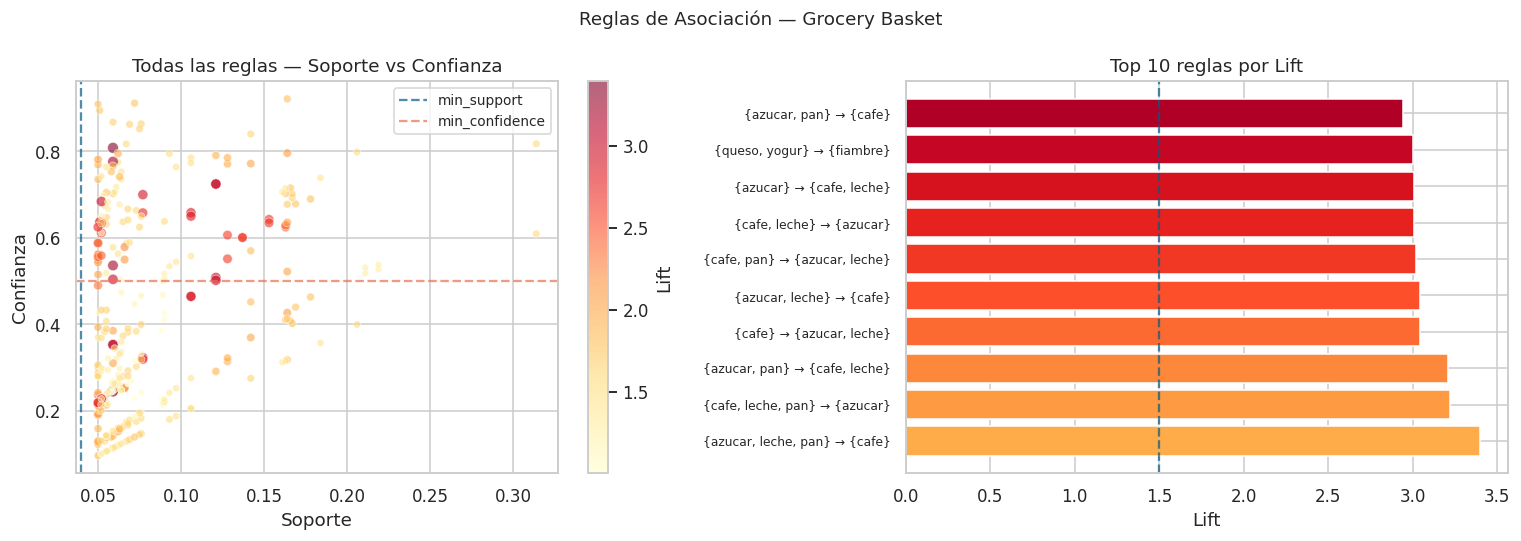

In [ ]:
# ── Scatter: Soporte vs Confianza, tamaño = Lift ─────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Todas las reglas
sc = ax1.scatter(
    reglas["support"], reglas["confidence"],
    c=reglas["lift"], cmap="YlOrRd",
    s=reglas["lift"]*15, alpha=0.6, edgecolors="white", linewidths=0.5
)
plt.colorbar(sc, ax=ax1, label="Lift")
ax1.axvline(0.04, color="#065A82", linestyle="--", alpha=0.7, label="min_support")
ax1.axhline(0.50, color="#E76F51", linestyle="--", alpha=0.7, label="min_confidence")
ax1.set_xlabel("Soporte")
ax1.set_ylabel("Confianza")
ax1.set_title("Todas las reglas — Soporte vs Confianza")
ax1.legend(fontsize=9)

# Top reglas por lift
top_n = reglas_filtradas.head(10).copy()
top_n["label"] = [
    f"{{{", ".join(sorted(a))}}} → {{{", ".join(sorted(c))}}}"
    for a, c in zip(top_n["antecedents"], top_n["consequents"])
]

ax2.barh(range(len(top_n)), top_n["lift"].values,
         color=plt.cm.YlOrRd(np.linspace(0.4, 0.9, len(top_n))),
         edgecolor="white")
ax2.set_yticks(range(len(top_n)))
ax2.set_yticklabels(top_n["label"].values, fontsize=8)
ax2.axvline(1.5, color="#065A82", linestyle="--", alpha=0.7)
ax2.set_xlabel("Lift")
ax2.set_title("Top 10 reglas por Lift")

plt.suptitle("Reglas de Asociación — Grocery Basket", fontsize=12)
plt.tight_layout()
plt.show()


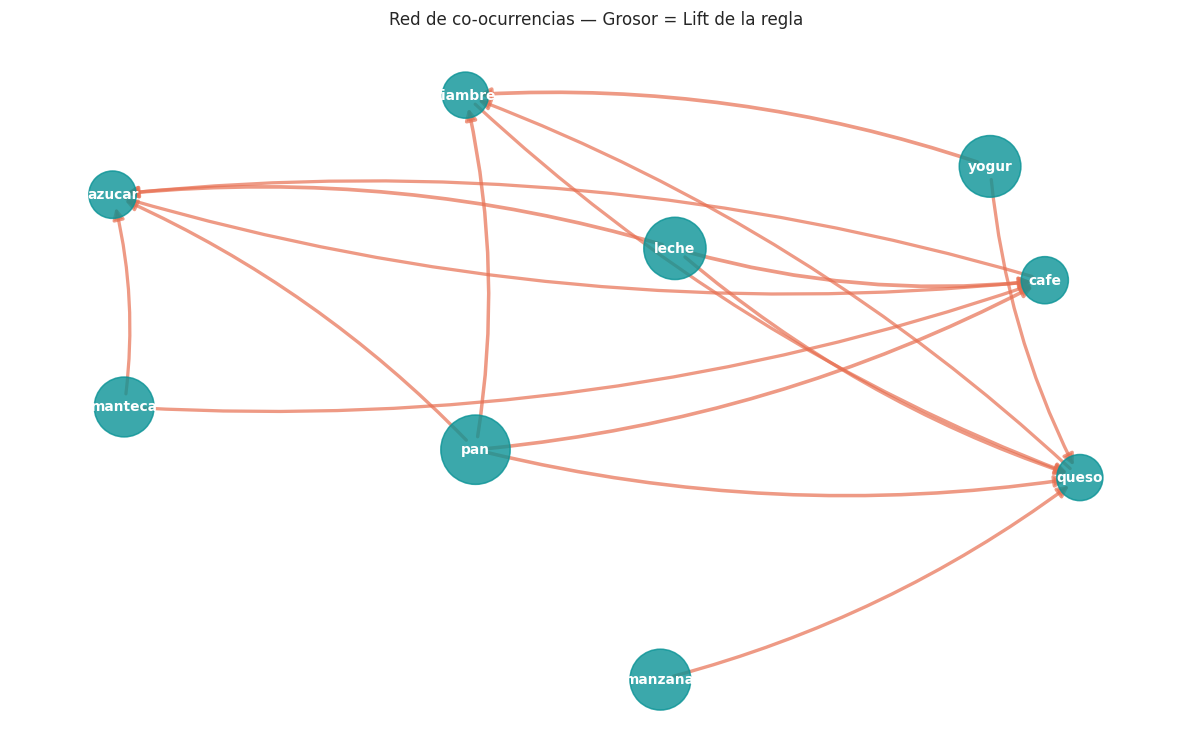

In [ ]:
# ── Red de items (co-ocurrencias) ────────────────────────────────────
try:
    import networkx as nx
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "networkx", "-q"])
    import networkx as nx

G = nx.DiGraph()

# Agregar aristas con las reglas de mayor lift (1 consecuente)
top_reglas = reglas_filtradas[
    reglas_filtradas["consequents"].apply(len) == 1
].head(18)

for _, row in top_reglas.iterrows():
    for ant in row["antecedents"]:
        con = list(row["consequents"])[0]
        weight = row["lift"]
        G.add_edge(ant, con, weight=weight, conf=row["confidence"])

plt.figure(figsize=(11, 7))
pos = nx.spring_layout(G, seed=42, k=2.5)

# Nodos con tamaño = frecuencia del producto
node_sizes = [freq.get(n, 0.05) * 4000 for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                        node_color="#0A9396", alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=9, font_color="white", font_weight="bold")

edges = G.edges(data=True)
widths = [d["weight"] * 0.8 for _, _, d in edges]
nx.draw_networkx_edges(G, pos, width=widths,
                        edge_color="#E76F51", alpha=0.7,
                        arrows=True, arrowsize=15,
                        connectionstyle="arc3,rad=0.1")

plt.title("Red de co-ocurrencias — Grosor = Lift de la regla", fontsize=11)
plt.axis("off")
plt.tight_layout()
plt.show()


### 1.6 Análisis de reglas específicas


In [ ]:
# ── Buscar reglas que involucren un producto específico ───────────────
def buscar_reglas(reglas, producto, como="antecedente"):
    """Filtra reglas donde el producto aparece como antecedente o consecuente."""
    if como == "antecedente":
        mask = reglas["antecedents"].apply(lambda x: producto in x)
    else:
        mask = reglas["consequents"].apply(lambda x: producto in x)
    resultado = reglas[mask].sort_values("lift", ascending=False)
    return resultado[["antecedents","consequents","support","confidence","lift"]]

# ¿Qué compran los que compran pan?
print("Reglas donde PAN es antecedente:")
display(buscar_reglas(reglas, "pan", "antecedente").head(8))

print("\nReglas donde LECHE es consecuente:")
display(buscar_reglas(reglas, "leche", "consecuente").head(8))


Reglas donde PAN es antecedente:


,antecedents,consequents,support,confidence,lift
103,"(leche, pan, azucar)",(cafe),0.059,0.8082,3.3959
102,"(leche, pan, cafe)",(azucar),0.059,0.7763,3.2212
109,"(pan, azucar)","(leche, cafe)",0.059,0.5364,3.2118
108,"(pan, cafe)","(leche, azucar)",0.059,0.5043,3.0196
95,"(pan, azucar)",(cafe),0.077,0.7000,2.9412
270,"(pan, fiambre)",(queso),0.106,0.6584,2.8877
271,"(pan, queso)",(fiambre),0.106,0.6503,2.8522
94,"(pan, cafe)",(azucar),0.077,0.6581,2.7308



Reglas donde LECHE es consecuente:


,antecedents,consequents,support,confidence,lift
112,(cafe),"(leche, pan, azucar)",0.059,0.2479,3.3959
113,(azucar),"(leche, pan, cafe)",0.059,0.2448,3.2212
109,"(pan, azucar)","(leche, cafe)",0.059,0.5364,3.2118
92,(cafe),"(leche, azucar)",0.121,0.5084,3.0443
108,"(pan, cafe)","(leche, azucar)",0.059,0.5043,3.0196
93,(azucar),"(leche, cafe)",0.121,0.5021,3.0064
287,(queso),"(leche, fiambre)",0.052,0.2281,2.7813
286,(fiambre),"(leche, queso)",0.052,0.2281,2.4524


In [ ]:
# ── Función para generar recomendación tipo "también te puede interesar" ──
def recomendar(carrito, reglas_df, top_n=5):
    """Dado un carrito de compras, recomienda productos frecuentemente co-comprados."""
    carrito_set = frozenset(carrito)
    candidatos = []

    for _, row in reglas_df.iterrows():
        # Si el antecedente es subconjunto del carrito
        if row["antecedents"].issubset(carrito_set):
            for item in row["consequents"]:
                if item not in carrito_set:
                    candidatos.append({
                        "producto": item,
                        "confianza": row["confidence"],
                        "lift": row["lift"]
                    })

    if not candidatos:
        return "No hay recomendaciones disponibles."

    df_rec = pd.DataFrame(candidatos)
    df_rec = df_rec.groupby("producto").agg(
        {"confianza": "max", "lift": "max"}
    ).sort_values("lift", ascending=False)
    return df_rec.head(top_n)

# Test
mi_carrito = ["pan", "manteca"]
print(f"Carrito: {mi_carrito}")
print("Recomendaciones:")
display(recomendar(mi_carrito, reglas_filtradas))

mi_carrito2 = ["leche", "cafe"]
print(f"\nCarrito: {mi_carrito2}")
print("Recomendaciones:")
display(recomendar(mi_carrito2, reglas_filtradas))


Carrito: ['pan', 'manteca']
Recomendaciones:


,confianza,lift
producto,,
huevos,0.5223,2.0244



Carrito: ['leche', 'cafe']
Recomendaciones:


,confianza,lift
producto,,
azucar,0.7246,3.0443


---
# 🏷️ PARTE 2 — Reglas de Clasificación: OneR y PRISM

Las reglas de clasificación predicen una clase (target) a partir de condiciones sobre las features.
Ejemplo: `SI Sex=mujer AND Pclass=1 → Sobrevivió`

| Algoritmo | Idea | Complejidad |
|-----------|------|-------------|
| **OneR** | La MEJOR regla usando UNA sola feature | Muy simple, muy interpretable |
| **PRISM** | Conjunto de reglas if-then por clase | Más completo, cobertura total |

**Dataset:** Titanic con variables **numéricas discretizadas** (Age→grupos) + **cualitativas** (Sex, Pclass, Embarked)


### 2.1 Preparar el dataset Titanic (mixto)


In [ ]:
# ── Cargar y preparar Titanic con variables mixtas ────────────────────
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_raw = pd.read_csv(url)

# Imputar
df_raw["Age"]      = df_raw["Age"].fillna(df_raw["Age"].median())
df_raw["Embarked"] = df_raw["Embarked"].fillna("S")

# ── Variables NUMÉRICAS → discretizar en categorías ─────────────────
df_raw["AgeGroup"] = pd.cut(
    df_raw["Age"],
    bins=[0, 12, 18, 35, 55, 100],
    labels=["Niño", "Adolescente", "Adulto joven", "Adulto", "Mayor"]
)

df_raw["FareGroup"] = pd.qcut(
    df_raw["Fare"],
    q=4,
    labels=["Bajo", "Medio-bajo", "Medio-alto", "Alto"]
)

# ── Variables CUALITATIVAS → conservar tal cual ─────────────────────
# Pclass (ordinal), Sex (binaria), Embarked (nominal), AgeGroup, FareGroup

FEATURES_CAT = ["Pclass", "Sex", "Embarked", "AgeGroup", "FareGroup"]
TARGET = "Survived"

df_cat = df_raw[FEATURES_CAT + [TARGET]].copy()
df_cat["Pclass"]   = df_cat["Pclass"].astype(str)
df_cat["AgeGroup"] = df_cat["AgeGroup"].astype(str)
df_cat["FareGroup"]= df_cat["FareGroup"].astype(str)

print(f"Shape: {df_cat.shape}")
print("\nPrimeras filas:")
display(df_cat.head(6))
print("\nDistribución de clases:")
print(df_cat[TARGET].value_counts(normalize=True).round(3))


Shape: (891, 6)

Primeras filas:


,Pclass,Sex,Embarked,AgeGroup,FareGroup,Survived
0,3,male,S,Adulto joven,Bajo,0
1,1,female,C,Adulto,Alto,1
2,3,female,S,Adulto joven,Medio-bajo,1
3,1,female,S,Adulto joven,Alto,1
4,3,male,S,Adulto joven,Medio-bajo,0
5,3,male,Q,Adulto joven,Medio-bajo,0



Distribución de clases:
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


### 2.2 OneR — La mejor regla de un solo atributo


In [ ]:
# ── Implementación de OneR ────────────────────────────────────────────
def one_r(X, y):
    """
    OneR: para cada feature, construye la regla de clasificación más simple
    (para cada valor de la feature, predice la clase mayoritaria).
    Retorna la mejor feature, sus reglas y la accuracy obtenida.
    """
    mejor_feature = None
    mejor_reglas  = None
    mejor_acc     = -1
    detalle       = {}

    for col in X.columns:
        reglas_col = {}
        errores    = 0

        for val in X[col].unique():
            mask    = X[col] == val
            clases  = y[mask]
            if len(clases) == 0:
                continue
            mayoria = clases.mode()[0]
            error_v = (clases != mayoria).sum()
            reglas_col[val] = {
                "clase": mayoria,
                "n_total": len(clases),
                "n_error": error_v,
                "precision": (clases == mayoria).mean()
            }
            errores += error_v

        acc = 1 - errores / len(y)
        detalle[col] = {"accuracy": acc, "reglas": reglas_col}

        if acc > mejor_acc:
            mejor_acc     = acc
            mejor_feature = col
            mejor_reglas  = reglas_col

    return mejor_feature, mejor_reglas, mejor_acc, detalle


X_cat = df_cat[FEATURES_CAT]
y_cat = df_cat[TARGET]

feat, reglas_oner, acc_oner, detalle_oner = one_r(X_cat, y_cat)

print(f"Mejor feature: {feat}")
print(f"Accuracy OneR: {acc_oner:.4f}")
print()
print("Reglas generadas:")
print(f"\n  SI {feat} = ... → Predice")
print("-" * 55)
for val, info in sorted(reglas_oner.items()):
    clase_str = "Sobrevivió" if info["clase"] == 1 else "No sobrevivió"
    print(f"  {feat} = {str(val):15} → {clase_str:15} "
          f"(prec={info['precision']:.2%}, n={info['n_total']})")


Mejor feature: Sex
Accuracy OneR: 0.7868

Reglas generadas:

  SI Sex = ... → Predice
-------------------------------------------------------
  Sex = female          → Sobrevivió      (prec=74.20%, n=314)
  Sex = male            → No sobrevivió   (prec=81.11%, n=577)


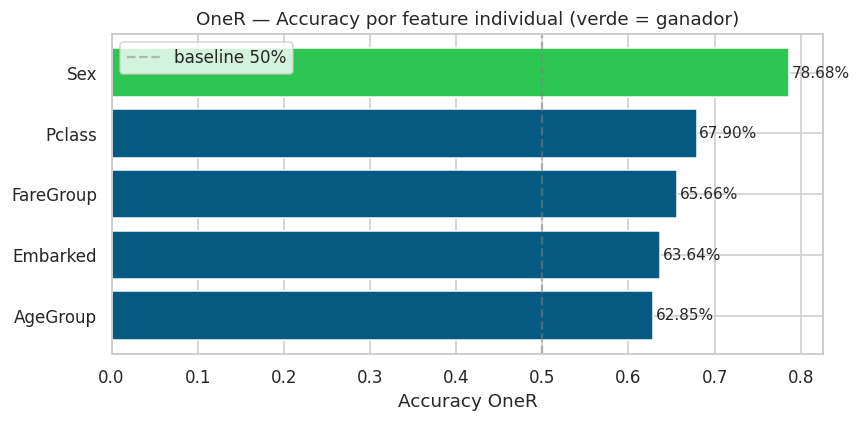

In [ ]:
# ── Comparativa de accuracy por feature ──────────────────────────────
acc_por_feature = {col: detalle_oner[col]["accuracy"] for col in detalle_oner}
df_acc = pd.Series(acc_por_feature).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
colores = ["#2DC653" if col == feat else "#065A82" for col in df_acc.index]
bars = plt.barh(df_acc.index, df_acc.values, color=colores, edgecolor="white")
plt.axvline(0.5, color="gray", linestyle="--", alpha=0.5, label="baseline 50%")
for bar, val in zip(bars, df_acc.values):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f"{val:.2%}", va="center", fontsize=10)
plt.xlabel("Accuracy OneR")
plt.title("OneR — Accuracy por feature individual (verde = ganador)")
plt.legend()
plt.tight_layout()
plt.show()


### 2.3 PRISM — Reglas if-then por clase


In [ ]:
# ── Implementación de PRISM (simplificado) ───────────────────────────
def prism(X, y, target_class, max_reglas=15, min_precision=0.6, min_cobertura=3):
    """
    PRISM: genera reglas if-then para la clase objetivo.
    Estrategia: añadir condiciones que maximicen la precisión,
    luego eliminar los ejemplos cubiertos y repetir.
    """
    remaining_X = X.copy()
    remaining_y = y.copy()
    reglas = []

    for _ in range(max_reglas):
        # Si ya no quedan positivos → terminar
        if (remaining_y == target_class).sum() == 0:
            break

        condiciones = {}
        current_X   = remaining_X.copy()
        current_y   = remaining_y.copy()

        # Añadir condiciones hasta precisión perfecta o sin mejora
        for _ in range(len(X.columns)):
            if len(current_X) == 0:
                break

            prec_actual = (current_y == target_class).mean()
            if prec_actual >= 1.0:
                break

            mejor_prec  = prec_actual
            mejor_attr  = None
            mejor_val   = None

            for col in current_X.columns:
                if col in condiciones:  # ya usada
                    continue
                for val in current_X[col].unique():
                    mask = current_X[col] == val
                    if mask.sum() < min_cobertura:
                        continue
                    prec = (current_y[mask] == target_class).mean()
                    if prec > mejor_prec:
                        mejor_prec = prec
                        mejor_attr = col
                        mejor_val  = val

            if mejor_attr is None:
                break  # no hay mejora posible

            condiciones[mejor_attr] = mejor_val
            mask = current_X[mejor_attr] == mejor_val
            current_X = current_X[mask]
            current_y = current_y[mask]

        # Evaluar la regla construida
        if not condiciones:
            break

        # Aplicar condiciones al conjunto restante
        cobertura = pd.Series([True]*len(remaining_X), index=remaining_X.index)
        for attr, val in condiciones.items():
            cobertura &= (remaining_X[attr] == val)

        n_cubiertos    = cobertura.sum()
        n_correctos    = (remaining_y[cobertura] == target_class).sum()
        precision_real = n_correctos / n_cubiertos if n_cubiertos > 0 else 0

        if n_cubiertos >= min_cobertura and precision_real >= min_precision:
            reglas.append({
                "condiciones":  condiciones,
                "clase":        target_class,
                "precision":    precision_real,
                "cobertura":    n_cubiertos,
                "n_correctos":  n_correctos
            })
            # Eliminar los ejemplos cubiertos (sólo los de la clase objetivo)
            positivos_cubiertos = cobertura & (remaining_y == target_class)
            remaining_X = remaining_X[~positivos_cubiertos]
            remaining_y = remaining_y[~positivos_cubiertos]
        else:
            break  # regla demasiado débil

    return reglas


# Ejecutar PRISM para cada clase
reglas_clase_1 = prism(X_cat, y_cat, target_class=1,
                        max_reglas=10, min_precision=0.65)
reglas_clase_0 = prism(X_cat, y_cat, target_class=0,
                        max_reglas=10, min_precision=0.65)

print(f"Reglas para Sobrevivió (1):      {len(reglas_clase_1)}")
print(f"Reglas para No sobrevivió (0):   {len(reglas_clase_0)}")


Reglas para Sobrevivió (1):      10
Reglas para No sobrevivió (0):   10


In [ ]:
# ── Mostrar las reglas PRISM en formato legible ───────────────────────
def mostrar_reglas_prism(reglas, nombre_clase):
    print(f"\n=== REGLAS PARA: {nombre_clase} ===")
    print("="*60)
    for i, r in enumerate(reglas, 1):
        conds = " AND ".join(
            f"{k} = {v}" for k, v in r["condiciones"].items()
        )
        print(f"Regla {i}: SI {conds}")
        print(f"         ENTONCES clase = {nombre_clase}")
        print(f"         (precision={r['precision']:.2%}, "
              f"cobertura={r['cobertura']}, "
              f"correctos={r['n_correctos']})")
        print()

mostrar_reglas_prism(reglas_clase_1, "SOBREVIVIÓ")
mostrar_reglas_prism(reglas_clase_0, "NO SOBREVIVIÓ")



=== REGLAS PARA: SOBREVIVIÓ ===
Regla 1: SI Sex = female AND Pclass = 1 AND AgeGroup = Mayor
         ENTONCES clase = SOBREVIVIÓ
         (precision=100.00%, cobertura=7, correctos=7)

Regla 2: SI Sex = female AND Pclass = 1 AND AgeGroup = Adolescente
         ENTONCES clase = SOBREVIVIÓ
         (precision=100.00%, cobertura=10, correctos=10)

Regla 3: SI Sex = female AND Pclass = 1 AND AgeGroup = Adulto joven AND Embarked = C
         ENTONCES clase = SOBREVIVIÓ
         (precision=100.00%, cobertura=19, correctos=19)

Regla 4: SI Sex = female AND Pclass = 1 AND AgeGroup = Adulto AND Embarked = S
         ENTONCES clase = SOBREVIVIÓ
         (precision=100.00%, cobertura=14, correctos=14)

Regla 5: SI Sex = female AND Pclass = 1 AND AgeGroup = Adulto joven
         ENTONCES clase = SOBREVIVIÓ
         (precision=96.15%, cobertura=26, correctos=25)

Regla 6: SI Sex = female AND Pclass = 2 AND Embarked = C
         ENTONCES clase = SOBREVIVIÓ
         (precision=100.00%, cobertura=7,

In [ ]:
# ── Aplicar las reglas PRISM para clasificar ─────────────────────────
def clasificar_prism(X, reglas_pos, reglas_neg, clase_default=0):
    """Clasifica usando las reglas PRISM generadas."""
    predicciones = []
    for idx in range(len(X)):
        fila = X.iloc[idx]
        pred = clase_default
        max_prec = 0

        # Evaluar reglas de clase 1
        for r in reglas_pos:
            aplica = all(fila[k] == v for k, v in r["condiciones"].items())
            if aplica and r["precision"] > max_prec:
                max_prec = r["precision"]
                pred = 1

        # Evaluar reglas de clase 0 (sólo si no hay regla de clase 1 más fuerte)
        for r in reglas_neg:
            aplica = all(fila[k] == v for k, v in r["condiciones"].items())
            if aplica and r["precision"] > max_prec:
                max_prec = r["precision"]
                pred = 0

        predicciones.append(pred)
    return np.array(predicciones)


y_pred_prism = clasificar_prism(X_cat, reglas_clase_1, reglas_clase_0)
acc_prism = accuracy_score(y_cat, y_pred_prism)

print(f"Accuracy PRISM: {acc_prism:.4f}")
print(f"Accuracy OneR:  {acc_oner:.4f}")
print()
print("Reporte PRISM:")
print(classification_report(y_cat, y_pred_prism,
                             target_names=["No sobrevivió", "Sobrevivió"]))


Accuracy PRISM: 0.7396
Accuracy OneR:  0.7868

Reporte PRISM:
               precision    recall  f1-score   support

No sobrevivió       0.70      1.00      0.83       549
   Sobrevivió       0.98      0.33      0.49       342

     accuracy                           0.74       891
    macro avg       0.84      0.66      0.66       891
 weighted avg       0.81      0.74      0.70       891



---
# 🌳 PARTE 3 — Árbol de Decisión como Extractor de Reglas

Un árbol de decisión puede verse como un **conjunto de reglas if-then**:
cada camino desde la raíz hasta una hoja es una regla completa.

Ventaja sobre PRISM: el árbol optimiza globalmente (todas las reglas a la vez)
y maneja variables **numéricas sin necesidad de discretizar**.


### 3.1 Variables numéricas y cualitativas juntas


In [ ]:
# ── Dataset Titanic con variables NUMÉRICAS + CUALITATIVAS originales ─
df_mixed = df_raw[["Pclass", "Age", "Fare", "SibSp", "Parch", "Sex", "Embarked", "Survived"]].copy()

# Codificar variables cualitativas para el árbol
df_mixed["Sex_n"]      = (df_mixed["Sex"] == "female").astype(int)
df_mixed["Embarked_n"] = df_mixed["Embarked"].map({"S":0, "C":1, "Q":2}).fillna(0)

FEATURES_NUM  = ["Pclass", "Age", "Fare", "SibSp", "Parch"]  # numéricas
FEATURES_QUAL = ["Sex_n", "Embarked_n"]                       # cualitativas codificadas
FEATURES_ALL  = FEATURES_NUM + FEATURES_QUAL

X_mix = df_mixed[FEATURES_ALL]
y_mix = df_mixed["Survived"]

FEATURE_NAMES = FEATURES_NUM + ["Sex(female=1)", "Embarked(S=0,C=1,Q=2)"]

print("Features numéricas:", FEATURES_NUM)
print("Features cualitativas:", ["Sex", "Embarked"])
print(f"\nShape: {X_mix.shape} | Sin nulos: {X_mix.isnull().sum().sum() == 0}")
display(X_mix.head(4))


Features numéricas: ['Pclass', 'Age', 'Fare', 'SibSp', 'Parch']
Features cualitativas: ['Sex', 'Embarked']

Shape: (891, 7) | Sin nulos: True


,Pclass,Age,Fare,SibSp,Parch,Sex_n,Embarked_n
0,3,22.0,7.2500,1,0,0,0
1,1,38.0,71.2833,1,0,1,1
2,3,26.0,7.9250,0,0,1,0
3,1,35.0,53.1000,1,0,1,0


### 3.2 Entrenar el árbol y extraer reglas


Accuracy Árbol (mixto): 0.7765



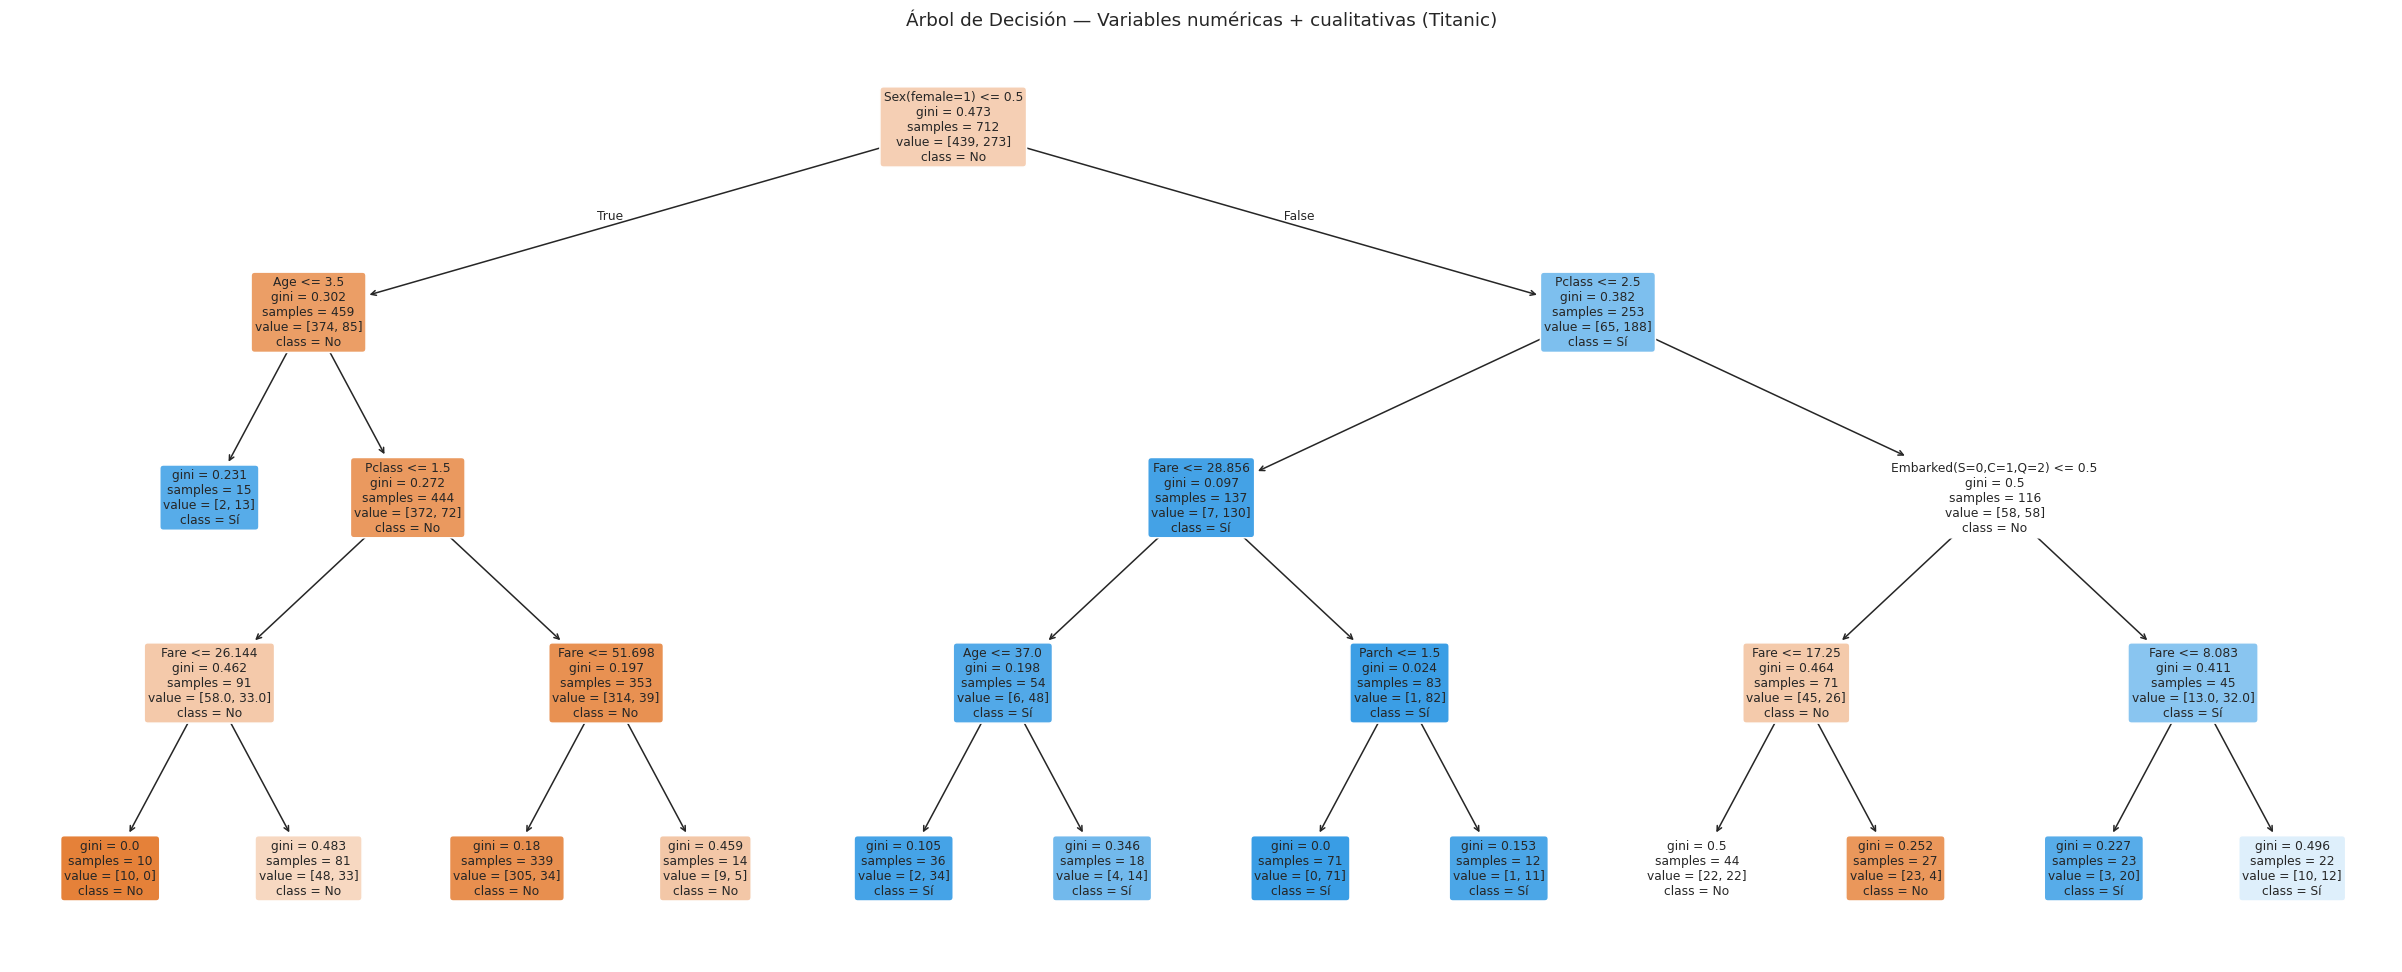

In [ ]:
# ── Árbol con variables mixtas ────────────────────────────────────────
X_tr_m, X_te_m, y_tr_m, y_te_m = train_test_split(
    X_mix, y_mix, test_size=0.2, random_state=42, stratify=y_mix
)

arbol = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    criterion="gini",
    random_state=42
)
arbol.fit(X_tr_m, y_tr_m)

y_pred_arbol = arbol.predict(X_te_m)
acc_arbol = accuracy_score(y_te_m, y_pred_arbol)
print(f"Accuracy Árbol (mixto): {acc_arbol:.4f}")
print()

# Visualizar el árbol
plt.figure(figsize=(22, 9))
plot_tree(
    arbol,
    feature_names=FEATURE_NAMES,
    class_names=["No", "Sí"],
    filled=True, rounded=True, fontsize=8
)
plt.title("Árbol de Decisión — Variables numéricas + cualitativas (Titanic)", fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# ── Extraer reglas en formato texto ───────────────────────────────────
print("Reglas extraídas del árbol (export_text):")
print("="*65)
print(export_text(arbol, feature_names=FEATURE_NAMES, max_depth=4))


Reglas extraídas del árbol (export_text):
|--- Sex(female=1) <= 0.50
|   |--- Age <= 3.50
|   |   |--- class: 1
|   |--- Age >  3.50
|   |   |--- Pclass <= 1.50
|   |   |   |--- Fare <= 26.14
|   |   |   |   |--- class: 0
|   |   |   |--- Fare >  26.14
|   |   |   |   |--- class: 0
|   |   |--- Pclass >  1.50
|   |   |   |--- Fare <= 51.70
|   |   |   |   |--- class: 0
|   |   |   |--- Fare >  51.70
|   |   |   |   |--- class: 0
|--- Sex(female=1) >  0.50
|   |--- Pclass <= 2.50
|   |   |--- Fare <= 28.86
|   |   |   |--- Age <= 37.00
|   |   |   |   |--- class: 1
|   |   |   |--- Age >  37.00
|   |   |   |   |--- class: 1
|   |   |--- Fare >  28.86
|   |   |   |--- Parch <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- Parch >  1.50
|   |   |   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- Embarked(S=0,C=1,Q=2) <= 0.50
|   |   |   |--- Fare <= 17.25
|   |   |   |   |--- class: 0
|   |   |   |--- Fare >  17.25
|   |   |   |   |--- class: 0
|   |   |--- Embarked(S=0,C=1,Q

### 3.3 Función: árbol → reglas if-then estructuradas


In [ ]:
# ── Recorrer el árbol y convertir cada hoja en una regla if-then ──────
def arbol_a_reglas(clf, feature_names, class_names=None):
    """
    Extrae todas las reglas del árbol como lista de diccionarios.
    Cada regla describe el camino desde la raíz hasta una hoja.
    """
    tree_  = clf.tree_
    reglas = []

    def recorrer(nodo, condiciones_actuales):
        # Si es hoja → guardar la regla
        if tree_.children_left[nodo] == -1:
            valores = tree_.value[nodo][0]
            clase_idx = np.argmax(valores)
            clase = class_names[clase_idx] if class_names else str(clase_idx)
            total = valores.sum()
            precision = valores[clase_idx] / total
            cobertura = int(total)

            reglas.append({
                "condiciones": list(condiciones_actuales),
                "clase":       clase,
                "precision":   round(precision, 4),
                "cobertura":   cobertura,
                "distribucion": {class_names[i]: int(v)
                                 for i, v in enumerate(valores)}
                                 if class_names else
                                 {str(i): int(v) for i, v in enumerate(valores)}
            })
            return

        feat  = feature_names[tree_.feature[nodo]]
        umbral = round(tree_.threshold[nodo], 3)

        # Rama izquierda: condición <= umbral
        recorrer(tree_.children_left[nodo],
                 condiciones_actuales + [f"{feat} <= {umbral}"])
        # Rama derecha: condición > umbral
        recorrer(tree_.children_right[nodo],
                 condiciones_actuales + [f"{feat} > {umbral}"])

    recorrer(0, [])
    return reglas


reglas_arbol = arbol_a_reglas(
    arbol,
    feature_names=FEATURE_NAMES,
    class_names=["No sobrevivió", "Sobrevivió"]
)

# Ordenar por precisión descendente
reglas_arbol.sort(key=lambda r: (-r["precision"], -r["cobertura"]))

print(f"Total de reglas extraídas del árbol: {len(reglas_arbol)}")
print()
print("TOP REGLAS por precisión:")
print("="*70)
for i, r in enumerate(reglas_arbol, 1):
    conds = " AND\n         ".join(r["condiciones"])
    print(f"Regla {i:02d}: SI {conds}")
    print(f"          ENTONCES {r['clase']}")
    print(f"          (precision={r['precision']:.2%}, "
          f"cobertura={r['cobertura']} casos)")
    print()

Total de reglas extraídas del árbol: 13

TOP REGLAS por precisión:
Regla 01: SI Sex(female=1) <= 0.5 AND
         Age > 3.5 AND
         Pclass <= 1.5 AND
         Fare <= 26.144
          ENTONCES No sobrevivió
          (precision=100.00%, cobertura=1 casos)

Regla 02: SI Sex(female=1) > 0.5 AND
         Pclass <= 2.5 AND
         Fare > 28.856 AND
         Parch <= 1.5
          ENTONCES Sobrevivió
          (precision=100.00%, cobertura=1 casos)

Regla 03: SI Sex(female=1) > 0.5 AND
         Pclass <= 2.5 AND
         Fare <= 28.856 AND
         Age <= 37.0
          ENTONCES Sobrevivió
          (precision=94.44%, cobertura=1 casos)

Regla 04: SI Sex(female=1) > 0.5 AND
         Pclass <= 2.5 AND
         Fare > 28.856 AND
         Parch > 1.5
          ENTONCES Sobrevivió
          (precision=91.67%, cobertura=1 casos)

Regla 05: SI Sex(female=1) <= 0.5 AND
         Age > 3.5 AND
         Pclass > 1.5 AND
         Fare <= 51.698
          ENTONCES No sobrevivió
          (precisi

In [ ]:
# ── Filtrar sólo reglas de alta calidad ──────────────────────────────
reglas_buenas = [
    r for r in reglas_arbol
    if r["precision"] >= 0.75 and r["cobertura"] >= 15
]

print(f"Reglas con precision >= 75% y cobertura >= 15: {len(reglas_buenas)}")
print()
for r in reglas_buenas:
    conds = " AND ".join(r["condiciones"])
    print(f"  [{r['clase']:15}] {conds}")
    print(f"  Prec={r['precision']:.1%}  Cobertura={r['cobertura']}")
    print()


Reglas con precision >= 75% y cobertura >= 15: 0



### 3.4 Feature Importance con variables mixtas


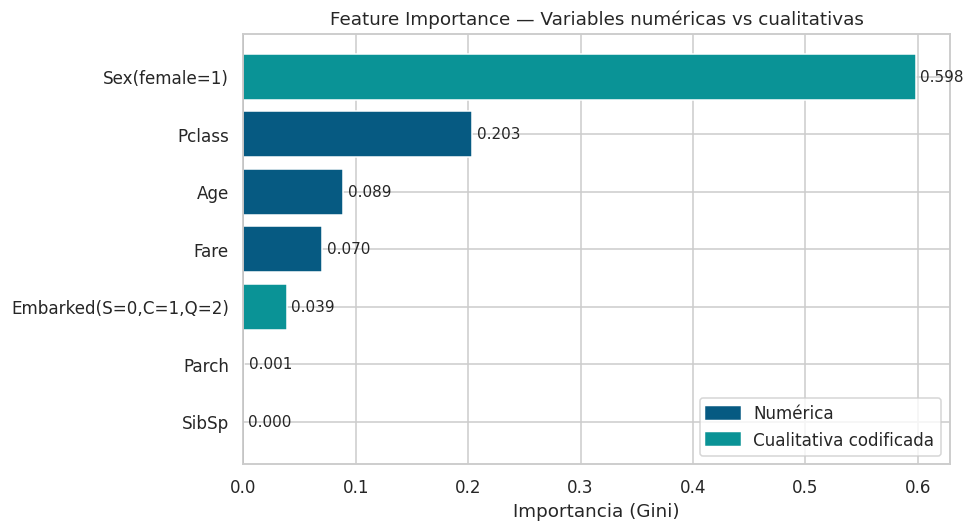

In [ ]:
# ── Importancia de variables numéricas vs cualitativas ────────────────
fi = pd.Series(arbol.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=True)

# Clasificar por tipo
num_features = FEATURES_NUM
qual_features_labels = ["Sex(female=1)", "Embarked(S=0,C=1,Q=2)"]

colores = ["#0A9396" if f in qual_features_labels else "#065A82" for f in fi.index]

plt.figure(figsize=(9, 5))
bars = plt.barh(fi.index, fi.values, color=colores, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.5)
for bar, val in zip(bars, fi.values):
    plt.text(val+0.004, bar.get_y()+bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=10)

patch_num  = mpatches.Patch(color="#065A82", label="Numérica")
patch_qual = mpatches.Patch(color="#0A9396", label="Cualitativa codificada")
plt.legend(handles=[patch_num, patch_qual], loc="lower right")
plt.title("Feature Importance — Variables numéricas vs cualitativas")
plt.xlabel("Importancia (Gini)")
plt.tight_layout()
plt.show()


---
# 📊 PARTE 4 — Comparativa Integral

Comparamos los 4 algoritmos de clasificación sobre el mismo dataset (Titanic).


In [ ]:
# ── Resumen de accuracy y características ────────────────────────────
comparativa = pd.DataFrame([
    {
        "Algoritmo":       "OneR",
        "Accuracy":        acc_oner,
        "N_Reglas":        len(reglas_oner),
        "Variables_usadas":1,
        "Interpretabilidad":"Muy alta",
        "Tipo_variables":  "Cualitativas (discr.)",
        "Escalabilidad":   "Alta",
    },
    {
        "Algoritmo":       "PRISM",
        "Accuracy":        acc_prism,
        "N_Reglas":        len(reglas_clase_1) + len(reglas_clase_0),
        "Variables_usadas":"Varias (por regla)",
        "Interpretabilidad":"Alta",
        "Tipo_variables":  "Cualitativas (discr.)",
        "Escalabilidad":   "Media",
    },
    {
        "Algoritmo":       "Arbol (depth=4)",
        "Accuracy":        acc_arbol,
        "N_Reglas":        len(reglas_arbol),
        "Variables_usadas":"Todas",
        "Interpretabilidad":"Alta (visual)",
        "Tipo_variables":  "Numericas + Cualit.",
        "Escalabilidad":   "Alta",
    },
])

display(comparativa.set_index("Algoritmo"))


,Accuracy,N_Reglas,Variables_usadas,Interpretabilidad,Tipo_variables,Escalabilidad
Algoritmo,,,,,,
OneR,0.786756,2,1,Muy alta,Cualitativas (discr.),Alta
PRISM,0.739618,20,Varias (por regla),Alta,Cualitativas (discr.),Media
Arbol (depth=4),0.776536,13,Todas,Alta (visual),Numericas + Cualit.,Alta


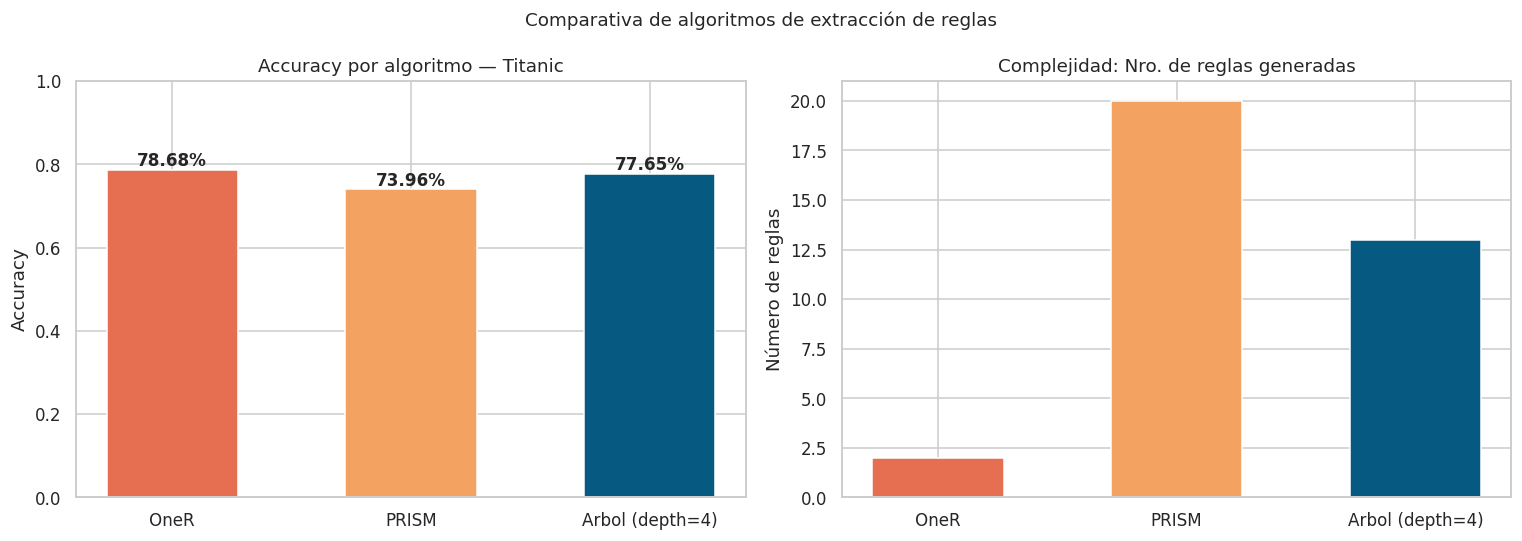

In [ ]:
# ── Gráfico comparativo de accuracy ──────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
algoritmos = comparativa["Algoritmo"]
accs        = comparativa["Accuracy"]
colores_bar = ["#E76F51", "#F4A261", "#065A82"]

bars = ax1.bar(algoritmos, accs, color=colores_bar, edgecolor="white", width=0.55)
ax1.set_ylim(0, 1)
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy por algoritmo — Titanic")
for bar, val in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f"{val:.2%}", ha="center", fontsize=11, fontweight="bold")

# Número de reglas
ax2.bar(algoritmos, comparativa["N_Reglas"],
        color=colores_bar, edgecolor="white", width=0.55)
ax2.set_ylabel("Número de reglas")
ax2.set_title("Complejidad: Nro. de reglas generadas")

plt.suptitle("Comparativa de algoritmos de extracción de reglas", fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# ── Guía de selección: cuándo usar cada algoritmo ────────────────────
guia = [
    # (Algoritmo, Usar cuando, No usar cuando)
    ("Apriori",
     "Dataset pequeño/mediano. Se quiere entender el proceso paso a paso.",
     "Dataset grande (lento). No sirve para clasificación."),

    ("FP-Growth",
     "Dataset grande. Mismo objetivo que Apriori pero más rápido.",
     "No sirve para clasificación. Árbol FP puede ser costoso en memoria."),

    ("OneR",
     "Baseline rápido. Explicar el modelo a audiencias no técnicas. Feature selection.",
     "Cuando la relación no es capturada por una sola variable."),

    ("PRISM",
     "Reglas legibles por humanos. Variables mayormente categóricas.",
     "Variables numéricas sin discretizar. Datasets muy grandes."),

    ("Árbol → Reglas",
     "Variables numéricas + cualitativas juntas. Mejor accuracy. Visualización.",
     "Cuando se necesitan reglas sin umbrales numéricos (e.g. Age > 13.5)."),
]

print("\n=== GUÍA DE SELECCIÓN ===")
print("="*75)
for algo, usar, no_usar in guia:
    print(f"\n{algo}:")
    print(f"  ✅ Usar cuando: {usar}")
    print(f"  ❌ Evitar si:   {no_usar}")



=== GUÍA DE SELECCIÓN ===

Apriori:
  ✅ Usar cuando: Dataset pequeño/mediano. Se quiere entender el proceso paso a paso.
  ❌ Evitar si:   Dataset grande (lento). No sirve para clasificación.

FP-Growth:
  ✅ Usar cuando: Dataset grande. Mismo objetivo que Apriori pero más rápido.
  ❌ Evitar si:   No sirve para clasificación. Árbol FP puede ser costoso en memoria.

OneR:
  ✅ Usar cuando: Baseline rápido. Explicar el modelo a audiencias no técnicas. Feature selection.
  ❌ Evitar si:   Cuando la relación no es capturada por una sola variable.

PRISM:
  ✅ Usar cuando: Reglas legibles por humanos. Variables mayormente categóricas.
  ❌ Evitar si:   Variables numéricas sin discretizar. Datasets muy grandes.

Árbol → Reglas:
  ✅ Usar cuando: Variables numéricas + cualitativas juntas. Mejor accuracy. Visualización.
  ❌ Evitar si:   Cuando se necesitan reglas sin umbrales numéricos (e.g. Age > 13.5).


---
<div style="background:#0D1B2A;color:#8BADC0;padding:20px 30px;border-radius:10px;font-family:sans-serif;">
  <p style="color:#0A9396;font-size:12px;letter-spacing:2px;margin:0 0 8px 0;">MINERÍA DE DATOS · 2026</p>
  <p style="font-size:15px;color:#FFFFFF;margin:0 0 6px 0;"><strong>Extracción de Reglas — resumen</strong></p>
  <table style="color:#A8D8EA;font-size:12px;border-collapse:collapse;width:100%">
    <tr><td style="padding:4px 12px"><strong>Apriori / FP-Growth</strong></td><td>Co-ocurrencias en transacciones → recomendaciones, market basket</td></tr>
    <tr><td style="padding:4px 12px"><strong>OneR</strong></td><td>Regla mínima de 1 feature → baseline e interpretación rápida</td></tr>
    <tr><td style="padding:4px 12px"><strong>PRISM</strong></td><td>Reglas if-then por clase → variables categóricas, alta legibilidad</td></tr>
    <tr><td style="padding:4px 12px"><strong>Árbol → Reglas</strong></td><td>Variables mixtas, mejor accuracy, visualización completa</td></tr>
  </table>
</div>
